Vocabulary Size : 24
Maximum Length : 4


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 64)     │      1,536 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 64)     │      1,536 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     98,816 │ embedding[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 4, 128),  │     98,816 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ lstm[0][1],       │
│                     │ (None, 128)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4, 24)     │      3,096 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 203,800 (796.09 KB)

 Trainable params: 203,800 (796.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4375 - loss: 3.1500  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5625 - loss: 3.0670 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 2.9245
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 2.6093
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5625 - loss: 2.0149
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5625 - loss: 1.6420
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5625 - loss: 1.6983
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5625 - loss: 1.6147
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 1.4917
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5625 - loss: 1.4736
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5625 - loss: 1.4528
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5625 -

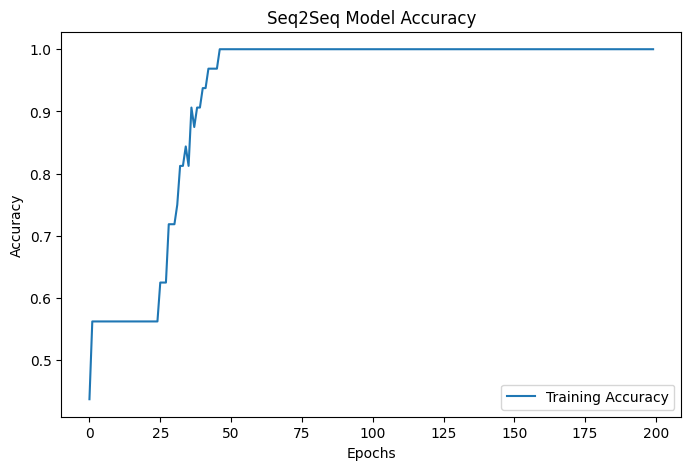

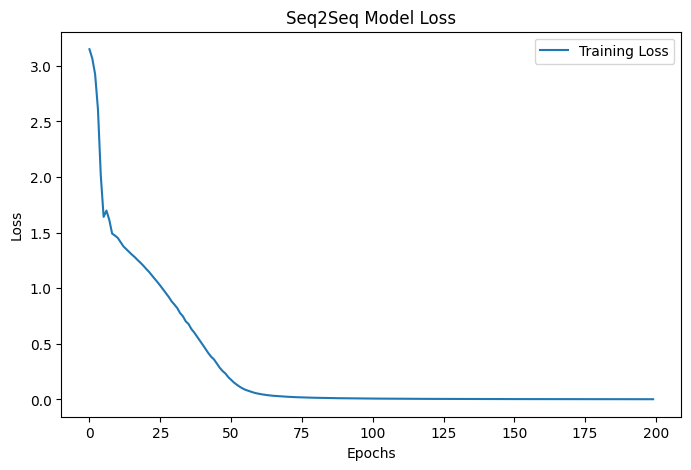

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step

Predicted Sequence : [15  0  0  0]


In [1]:
# Experiment No. 7
# Title: Sequence-to-Sequence (Seq2Seq) Model using LSTM

# Aim:
# To implement Sequence-to-Sequence (Seq2Seq) architecture
# using Encoder-Decoder LSTM Network in TensorFlow and Keras.

# Import Required Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample Text Dataset
input_texts = [
    "hello",
    "how are you",
    "good morning",
    "thank you",
    "see you",
    "good night",
    "welcome",
    "have a nice day"
]

target_texts = [
    "hi",
    "i am fine",
    "morning",
    "welcome",
    "bye",
    "sweet dreams",
    "thank you",
    "same to you"
]

# Initialize Tokenizer
tokenizer = Tokenizer()

# Fit Tokenizer
tokenizer.fit_on_texts(
    input_texts + target_texts
)

# Convert Text to Sequences
input_sequences = tokenizer.texts_to_sequences(
    input_texts
)

target_sequences = tokenizer.texts_to_sequences(
    target_texts
)

# Maximum Sequence Length
max_len = max(
    max(len(seq) for seq in input_sequences),
    max(len(seq) for seq in target_sequences)
)

# Pad Sequences
encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='post'
)

decoder_input_data = pad_sequences(
    target_sequences,
    maxlen=max_len,
    padding='post'
)

# Vocabulary Size
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size :", vocab_size)
print("Maximum Length :", max_len)

# One Hot Encode Target Data
decoder_target_data = tf.keras.utils.to_categorical(
    decoder_input_data,
    num_classes=vocab_size
)

# Parameters
embedding_dim = 64
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(max_len,))

encoder_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)(encoder_inputs)

encoder_lstm = LSTM(
    latent_dim,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_embedding
)

encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(max_len,))

decoder_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

decoder_dense = Dense(
    vocab_size,
    activation='softmax'
)

decoder_outputs = decoder_dense(decoder_outputs)

# Build Seq2Seq Model
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=2,
    epochs=200,
    verbose=1
)

# Evaluate Model
loss, accuracy = model.evaluate(
    [encoder_input_data, decoder_input_data],
    decoder_target_data
)

print("\nModel Loss :", loss)
print("Model Accuracy :", accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Seq2Seq Model Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Seq2Seq Model Loss')
plt.legend()

plt.show()

# Predict Sample
prediction = model.predict(
    [encoder_input_data[:1], decoder_input_data[:1]]
)

predicted_word = np.argmax(prediction[0], axis=1)

print("\nPredicted Sequence :", predicted_word)

# Conclusion
# Successfully implemented Sequence-to-Sequence (Seq2Seq)
# architecture using Encoder-Decoder LSTM Network
# in TensorFlow and Keras.